In [4]:
import numpy as np
import pandas as pd
import scanpy as sc

import plotnine as p9

import liana as li
import decoupler as dc
import omnipath as op

# Import DESeq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

import muon as mu
from muon import MuData

In [5]:
# Obtain TF regulons
net = dc.op.collectri(organism='human', remove_complexes=False, license='academic', verbose=False)

# Load & Prep Data

In [ ]:
mdata = mu.read("/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/python_objekte/gated_sepsis_with_metmdata.h5mu")
#mdata = mu.read("/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/python_objekte/gated_ImmuneAging_with_metmdata.h5mu")
#mdata = mu.read("/nfs/home/students/i.kaciran/FoPra_PLAs/data/datasets/python_objekte/gated_skin_with_metmdata.h5mu")

mdata

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/mudata/_core/mudata.py:613: UserWarning: Cannot join columns with the same name because var_names are intersecting.


MuData object with n_obs × n_vars = 285043 × 37679
  obs:	'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'sample', 'donor_id', 'cell_barcodes', 'scRNA.seq', 'TCR', 'BCR', 'CITE.seq', 'Bulk.RNA.seq', 'Olink.proteomics', 'Gender', 'Age', 'Sample.Collection.Date', 'Sample.Collection.Site', 'Group', 'Sepsis.Infection.Source', 'Ethnicity', 'Chronic.comorbidity.None', 'Cardiovascular.compromise', 'COPD', 'Hypertension', 'Diabetes', 'Respiratory.insufficiency', 'Renal.insufficiency', 'Tuberculosis', 'Length.of.ICU.stay.days', 'Length.of.hospital.stay.days', 'X14.day.mortality..Deceased.1.Living.0.', 'X28.day.mortality..Deceased.1.Living.0.', 'X90.day.mortality..Deceased.1.Living.0.', 'Gram.positive.bacteria', 'Gram.negative.bacteria', 'Virus', 'Fungi', 'Microbiology.laboratory..Unknown', 'SOFA.score', 'Shock', 'Organ.failure', 'Mechanical.ventilation', 'percent.mt', 'percent.ribo', 'percent.hb', 'mt_outlier_all', 'is_outlier_RNA', 'is_outlier_protein', 'is_outlier', 'scDblFinder.class', 'scDblFinder.score', 'RNA_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.25', 'RNA.weight', 'ADT.weight', 'leiden_0.8_totalVI', 'leiden_0.25_totalVI', 'celltype_full', 'lineage', 'pla_status', 'celltype', 'Dataset', 'Cohort', 'Condition', 'Sex', 'Ethnicity_Race', 'inner_batch_effect', 'patient_ID', 'sample_ID'
  2 modalities
    rna:	285043 × 37471
    adt:	285043 × 208

In [8]:
object = "sepsis"
#object = "immuneAging"
#object = "skin"

Define cols of interest from .obs.

In [9]:
# sepsis
sample_key = 'sample'
groupby = 'lineage' # for pseudobulk profiles
condition_key = 'pla_status'

# Differential Testing

In [ ]:
adata = mdata["rna"].copy()

cols = ["sample", "patient_ID", "lineage", "pla_status"]
adata.obs[cols] = mdata.obs.loc[adata.obs_names, cols]

# merge missing celltypes into Unassigned
adata.obs[groupby] = adata.obs[groupby].fillna("Unassigned")

# missing condition to platelet-free
adata.obs[condition_key] = adata.obs[condition_key].fillna("platelet-free")

# one pseudobulk replicate for every biological sample × PLA state
adata.obs["pb_sample"] = (
    adata.obs["sample"].astype(str)
    + "__"
    + adata.obs["pla_status"].astype(str)
)

sample_key = "pb_sample"

In [40]:
print(adata.obs["pb_sample"])

cell_barcode
GSM8571042_Abd-S111_AAACCTGAGCAGCCTC-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGAGCGAAGGG-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGAGCGGCTTC-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGAGTGTACTC-1    GSM8571042_Abd-S111__platelet-free
GSM8571042_Abd-S111_AAACCTGCAGGGCATA-1    GSM8571042_Abd-S111__platelet-free
                                                         ...                
GSM8571081_Uri-S88_TTTGTCAGTGCTAGCC-1                GSM8571081_Uri-S88__PLA
GSM8571081_Uri-S88_TTTGTCATCAAGATCC-1      GSM8571081_Uri-S88__platelet-free
GSM8571081_Uri-S88_TTTGTCATCCCTCAGT-1                GSM8571081_Uri-S88__PLA
GSM8571081_Uri-S88_TTTGTCATCGCTAGCG-1                GSM8571081_Uri-S88__PLA
GSM8571081_Uri-S88_TTTGTCATCTGGCGTG-1      GSM8571081_Uri-S88__platelet-free
Name: pb_sample, Length: 285043, dtype: object


In [42]:
pdata = dc.pp.pseudobulk(
    adata,
    sample_col=sample_key,
    groups_col=groupby,
    layer=None,
    mode="sum"
)

pdata

AnnData object with n_obs × n_vars = 640 × 37471
    obs: 'pb_sample', 'lineage', 'sample', 'patient_ID', 'pla_status', 'psbulk_cells', 'psbulk_counts'
    layers: 'psbulk_props'

In [43]:
# filter samples based on number of cells and counts
dc.pp.filter_samples(pdata, min_cells = 10, min_counts=1000)

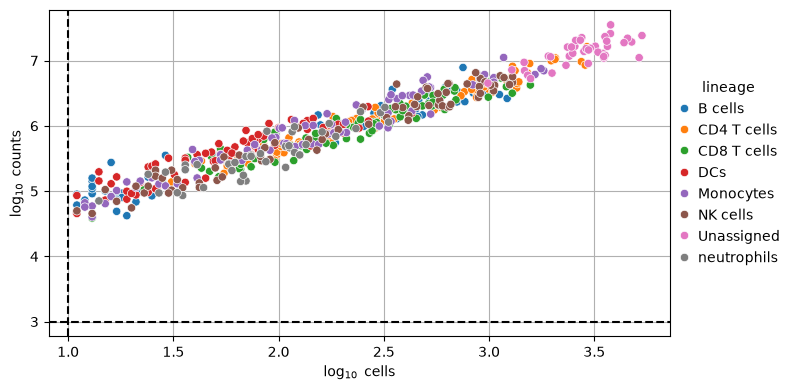

In [45]:
dc.pl.filter_samples(
    pdata,
    groupby=groupby,
    figsize=(8, 4)
)

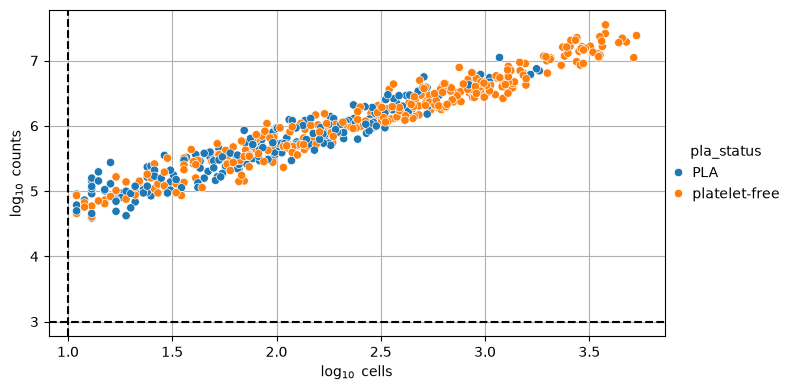

In [46]:
dc.pl.filter_samples(
    pdata,
    groupby=condition_key,
    figsize=(8, 4)
)

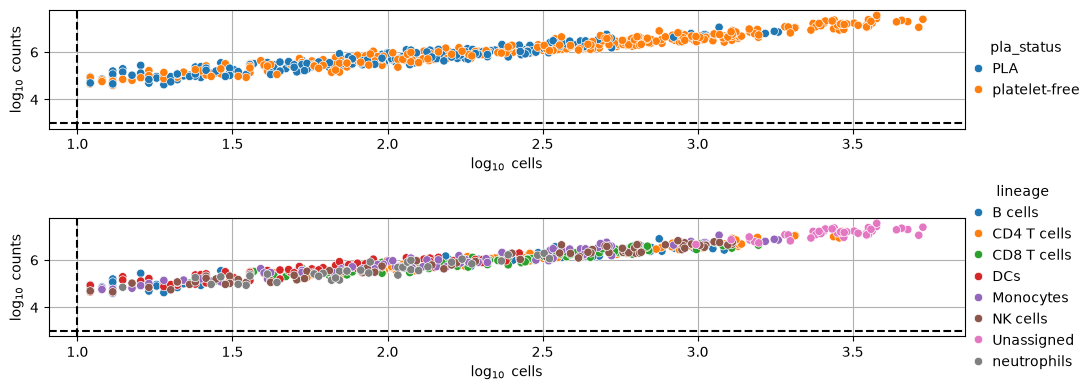

In [48]:
dc.pl.filter_samples(pdata, groupby=[condition_key, groupby], figsize=(11, 4))

x = how many single cells contributed to that pseudobulk
y = total RNA counts summed across those cells

In [49]:
pdata.obs.groupby(groupby)["psbulk_cells"].describe()

,count,mean,std,min,25%,50%,75%,max
lineage,,,,,,,,
B cells,64.0,331.046875,378.735340,10.0,17.75,210.5,525.25,1982.0
CD4 T cells,80.0,634.112500,687.532756,30.0,118.75,293.0,963.75,2918.0
CD8 T cells,80.0,336.300000,314.973714,12.0,108.50,256.5,483.75,1570.0
DCs,73.0,78.109589,74.924140,10.0,25.00,53.0,99.00,428.0
Monocytes,76.0,321.552632,413.376548,11.0,49.25,149.5,420.75,1819.0
NK cells,76.0,449.842105,530.154369,10.0,49.75,341.5,645.25,3485.0
Unassigned,40.0,2937.600000,1042.642275,987.0,2347.50,2899.0,3554.75,5327.0
neutrophils,40.0,105.250000,81.893849,13.0,53.50,77.0,119.75,332.0


In [53]:
tmp = (
    pdata.obs
    .groupby(["sample", groupby, "pla_status"], observed=True)
    .size()
    .unstack("pla_status", fill_value=0)
)

tmp

pla_status                       PLA  platelet-free
sample              lineage                        
GSM8571042_Abd-S111 B cells        1              1
                    CD4 T cells    1              1
                    CD8 T cells    1              1
                    DCs            1              1
                    Monocytes      1              1
...                              ...            ...
GSM8571081_Uri-S88  DCs            1              1
                    Monocytes      1              1
                    NK cells       1              1
                    Unassigned     0              1
                    neutrophils    0              1

[318 rows x 2 columns]

# Differential Expression Analysis

- edgeR-like filtering using decoupler-py
- then differential expression analysis using pydeseq2 package
- re-implementation of the original DESeq2 method

sequencing reads -> UMI counts per gene per cell -> sum across cells -> pseudobulk gene counts per patient/sample

In [62]:
dea_results = {}
quiet = True

for cell_group in pdata.obs[groupby].unique():

    # select pseudobulks for one lineage/cell type
    ctdata = pdata[pdata.obs[groupby] == cell_group].copy()

    # filter low-expression genes
    dc.pp.filter_by_expr(
        ctdata,
        group=condition_key,
        min_count=5,
        min_total_count=10
    )
    
    ctdata.obs[condition_key] = (
        ctdata.obs[condition_key]
        .astype("category")
        .cat.set_categories(
            ["platelet-free", "PLA"],
            ordered=True
        )
    )
    
    counts = ctdata.obs[condition_key].value_counts()

    print(
        cell_group,
        ctdata.n_obs,
        "pseudobulks,",
        ctdata.n_vars,
        "genes"
    )

    print(counts)
    
    # keep the data, but don't fit an impossible contrast
    if counts.get("PLA", 0) == 0 or counts.get("platelet-free", 0) == 0:
        print(f"Skipping DE for {cell_group}: only one PLA-status present")
        continue

    # Paired DESeq2 design:
    # control for biological sample, test PLA status
    dds = DeseqDataSet(
        adata=ctdata,
        design_factors=["sample", condition_key],
        refit_cooks=True,
        quiet=quiet
    )
    
    # compute LFCs
    dds.deseq2()
    
    # contrast between pla and platelet-free
    stat_res = DeseqStats(
        dds,
        contrast=[condition_key, "PLA", "platelet-free"],
        quiet=quiet
    )
    
    # wald test
    stat_res.summary()
    
    # shrink lfcs
    stat_res.lfc_shrink(coeff="pla_status[T.PLA]")
    
    dea_results[cell_group] = stat_res.results_df

B cells 64 pseudobulks, 10214 genes
pla_status
platelet-free    40
PLA              24
Name: count, dtype: int64


/tmp/ipykernel_254420/3000193476.py:45: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


CD4 T cells 80 pseudobulks, 10189 genes
pla_status
platelet-free    40
PLA              40
Name: count, dtype: int64


/tmp/ipykernel_254420/3000193476.py:45: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.


CD8 T cells 80 pseudobulks, 9618 genes
pla_status
platelet-free    40
PLA              40
Name: count, dtype: int64


...

Monocytes 76 pseudobulks, 8941 genes
pla_status
PLA              40
platelet-free    36
Name: count, dtype: int64


/tmp/ipykernel_254420/3000193476.py:45: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.


NK cells 76 pseudobulks, 10537 genes
pla_status
platelet-free    40
PLA              36
Name: count, dtype: int64


/tmp/ipykernel_254420/3000193476.py:45: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.


Unassigned 40 pseudobulks, 13423 genes
pla_status
platelet-free    40
PLA               0
Name: count, dtype: int64
Skipping DE for Unassigned: only one PLA-status present
neutrophils 40 pseudobulks, 4892 genes
pla_status
platelet-free    40
PLA               0
Name: count, dtype: int64
Skipping DE for neutrophils: only one PLA-status present


In [63]:
pd.crosstab(
    adata.obs[groupby],
    adata.obs[condition_key]
)

pla_status,PLA,platelet-free
lineage,,
B cells,488,20788
CD4 T cells,5680,45049
CD8 T cells,7504,19400
DCs,2298,3440
Monocytes,20992,3479
NK cells,2443,31768
Unassigned,0,117504
neutrophils,0,4210


In [65]:
# concat results across cell types
dea_df = pd.concat(
    dea_results,
    names=[groupby, "gene"]
)

dea_df = dea_df.reset_index(level=0)

dea_df.head()

,lineage,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,,
ATAD3B,B cells,6.297904,-0.003021,0.216333,-0.002974,0.997627,0.998496
THAP3,B cells,9.358917,-0.505312,0.258945,-1.900466,0.057372,0.120275
PRKCZ,B cells,4.836472,-0.699691,0.368031,-1.958713,0.050146,0.107790
ACAP3,B cells,8.688481,0.442186,0.235132,1.897241,0.057796,0.120936
PUSL1,B cells,6.897306,0.103038,0.232913,0.418754,0.675396,0.770474


In [67]:
# PyDeseq Seems to intrdoce NAs for some p-values
# NOTE: there sometimes some NaN being introduced, best to double check that
len(dea_df[dea_df.isna().any(axis=1)])
dea_df.isna().sum().sort_values(ascending=False)

padj              1004
baseMean             0
lineage              0
log2FoldChange       0
lfcSE                0
stat                 0
pvalue               0
dtype: int64

In [68]:
print(
    f"{dea_df.isna().any(axis=1).sum()} / {len(dea_df)} "
    f"({dea_df.isna().any(axis=1).mean():.2%})"
)

1004 / 56570 (1.77%)


In [69]:
dea_df.assign(has_na=dea_df.isna().any(axis=1)) \
      .groupby(groupby)["has_na"] \
      .agg(["sum", "mean"])

,sum,mean
lineage,,
B cells,595,0.058253
CD4 T cells,0,0.000000
CD8 T cells,0,0.000000
DCs,0,0.000000
Monocytes,0,0.000000
NK cells,409,0.038816


In [72]:
for ct in pdata.obs[groupby].unique():

    tmp = pdata.obs[pdata.obs[groupby] == ct]

    pair_table = pd.crosstab(
        tmp["sample"],
        tmp["pla_status"]
    )

    complete = (
        (pair_table.get("PLA", 0) > 0) &
        (pair_table.get("platelet-free", 0) > 0)
    )

    print(
        ct,
        "complete pairs:",
        complete.sum(),
        "/",
        len(pair_table)
    )

B cells complete pairs: 24 / 40
CD4 T cells complete pairs: 40 / 40
CD8 T cells complete pairs: 40 / 40
DCs complete pairs: 35 / 38
Monocytes complete pairs: 36 / 40
NK cells complete pairs: 36 / 40
Unassigned complete pairs: 0 / 40
neutrophils complete pairs: 0 / 40


# DEA to Ligand-Receptor Interactions

In [73]:
adata_lr = mdata["rna"].copy()

# copy required metadata into RNA AnnData
cols = [condition_key, groupby]
adata_lr.obs[cols] = mdata.obs.loc[adata_lr.obs_names, cols]

# keep only PLA cells
adata_lr = adata_lr[
    adata_lr.obs[condition_key] == "PLA"
].copy()

# normalize RNA expression for LIANA expression/proportion calculations
sc.pp.normalize_total(adata_lr, target_sum=1e4)
sc.pp.log1p(adata_lr)

In [75]:
lr_res = li.multi.df_to_lr(
    adata_lr,
    dea_df=dea_df,
    resource_name="consensus",
    expr_prop=0.1,
    groupby=groupby,
    stat_keys=["stat", "pvalue", "padj"],
    use_raw=False,
    complex_col="stat",
    verbose=True,
    return_all_lrs=False,
)

lr_res = lr_res.sort_values(
    "interaction_stat",
    ascending=False,
    key=abs
)

lr_res.head()

Using resource `consensus`.
Using `.X`!
12537 features of mat are empty, they will be removed.
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:164: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
Features in adata and dea_df are mismatched.
0.64 of entities in the resource are missing from the data.


,ligand,receptor,ligand_complex,receptor_complex,source,ligand_stat,ligand_pvalue,ligand_padj,ligand_expr,ligand_props,...,receptor_pvalue,receptor_padj,receptor_expr,receptor_props,interaction_stat,interaction_pvalue,interaction_padj,interaction_expr,interaction_props,interaction
19,ANXA1,FPR1,ANXA1,FPR1,B cells,24.265165,4.574194e-130,6.285596e-127,0.854694,0.440574,...,2.649683e-86,6.535205e-84,0.646531,0.391393,21.977364,1.324841e-86,3.267602e-84,0.750613,0.415984,ANXA1^FPR1
116,VCAN,TLR2,VCAN,TLR2,B cells,23.303557,4.079986e-120,3.270449e-117,1.164666,0.446721,...,3.647582e-90,1.063215e-87,0.228230,0.200820,21.719248,1.823791e-90,5.316074e-88,0.696448,0.323770,VCAN^TLR2
111,S100A9,CD36,S100A9,CD36,B cells,25.062234,1.284297e-138,4.117886e-135,3.020891,0.733607,...,1.599585e-74,2.652829e-72,0.557917,0.362705,21.663145,7.997924e-75,1.326414e-72,1.789404,0.548156,S100A9^CD36
133,S100A12,CD36,S100A12,CD36,B cells,24.730745,4.995994e-135,1.201412e-131,1.433776,0.485656,...,1.599585e-74,2.652829e-72,0.557917,0.362705,21.497400,7.997924e-75,1.326414e-72,0.995847,0.424180,S100A12^CD36
109,S100A9,TLR4,S100A9,TLR4,B cells,25.062234,1.284297e-138,4.117886e-135,3.020891,0.733607,...,4.267208e-69,5.700872e-67,0.208033,0.186475,21.315543,2.133604e-69,2.850436e-67,1.614462,0.460041,S100A9^TLR4


# Visualizing

Moreover, by averaging the statistics across the ligand and receptor, we are focusing on the interactions for which both the ligand and receptor are deregulated in the same direction, i.e. both up or both down. However, this might ignore interactions in which e.g. the the ligand is deregulated while the receptor is not, or such where they are deregulated in opposite directions. These could represent potential inhibitory mechanisms, but we leave this to the user to explore.

<Axes: >

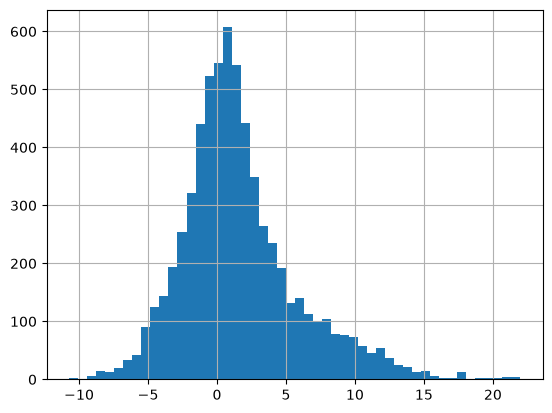

In [76]:
# Let's visualize how this looks like for all interactions  (across all cell types)
lr_res = lr_res.sort_values("interaction_stat", ascending=False)
lr_res['interaction_stat'].hist(bins=50)

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/layer.py:374: PlotnineWarning: geom_text : Removed 248 rows containing missing values.


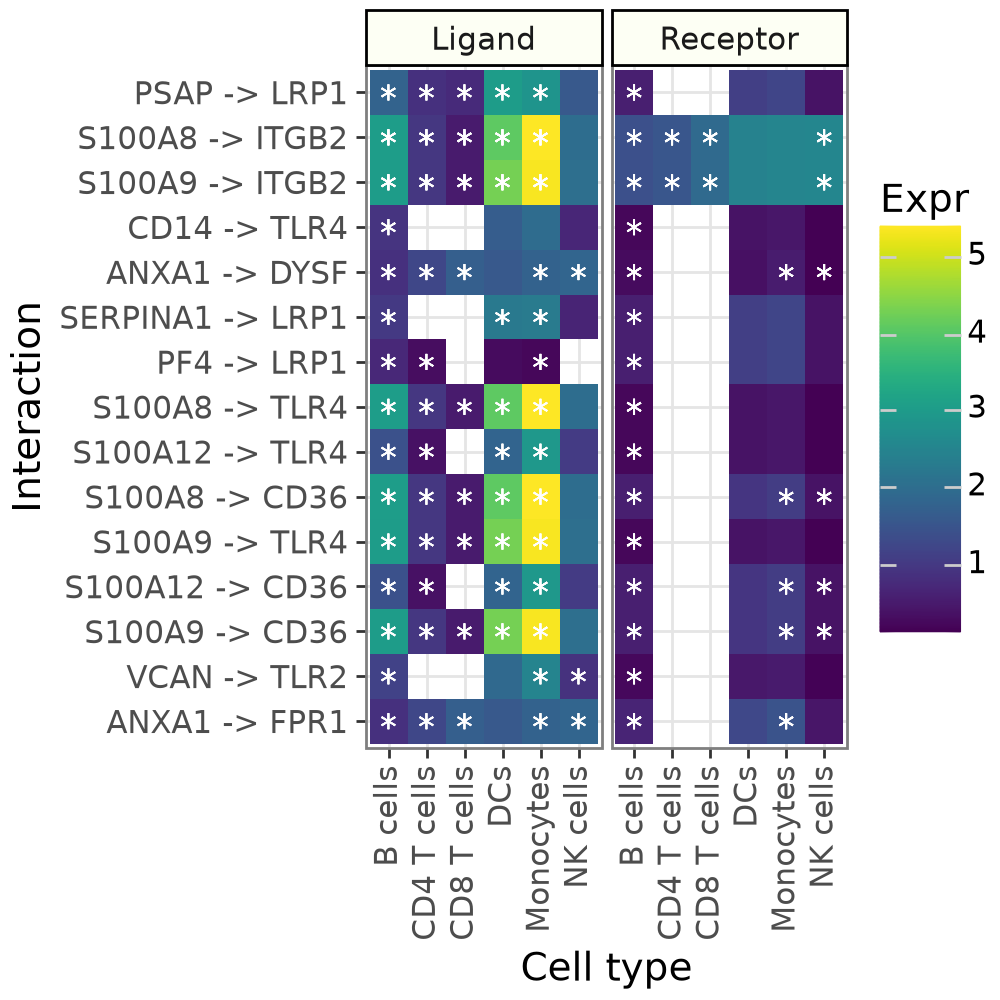

In [77]:
li.pl.tileplot(liana_res=lr_res,
               fill = 'expr',
               label='padj',
               label_fun = lambda x: '*' if x < 0.05 else np.nan,
               top_n=15,
               orderby = 'interaction_stat',
               orderby_ascending = False,
               orderby_absolute = False,
               source_title='Ligand',
               target_title='Receptor',
               )

/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/nfs/home/students/i.kaciran/.conda/envs/liana_py/lib/python3.11/site-packages/plotnine/scales/scales.py:48: PlotnineWarning: Scale for 'color' is already present.
Adding another scale for 'color',
which will replace the existing scale.



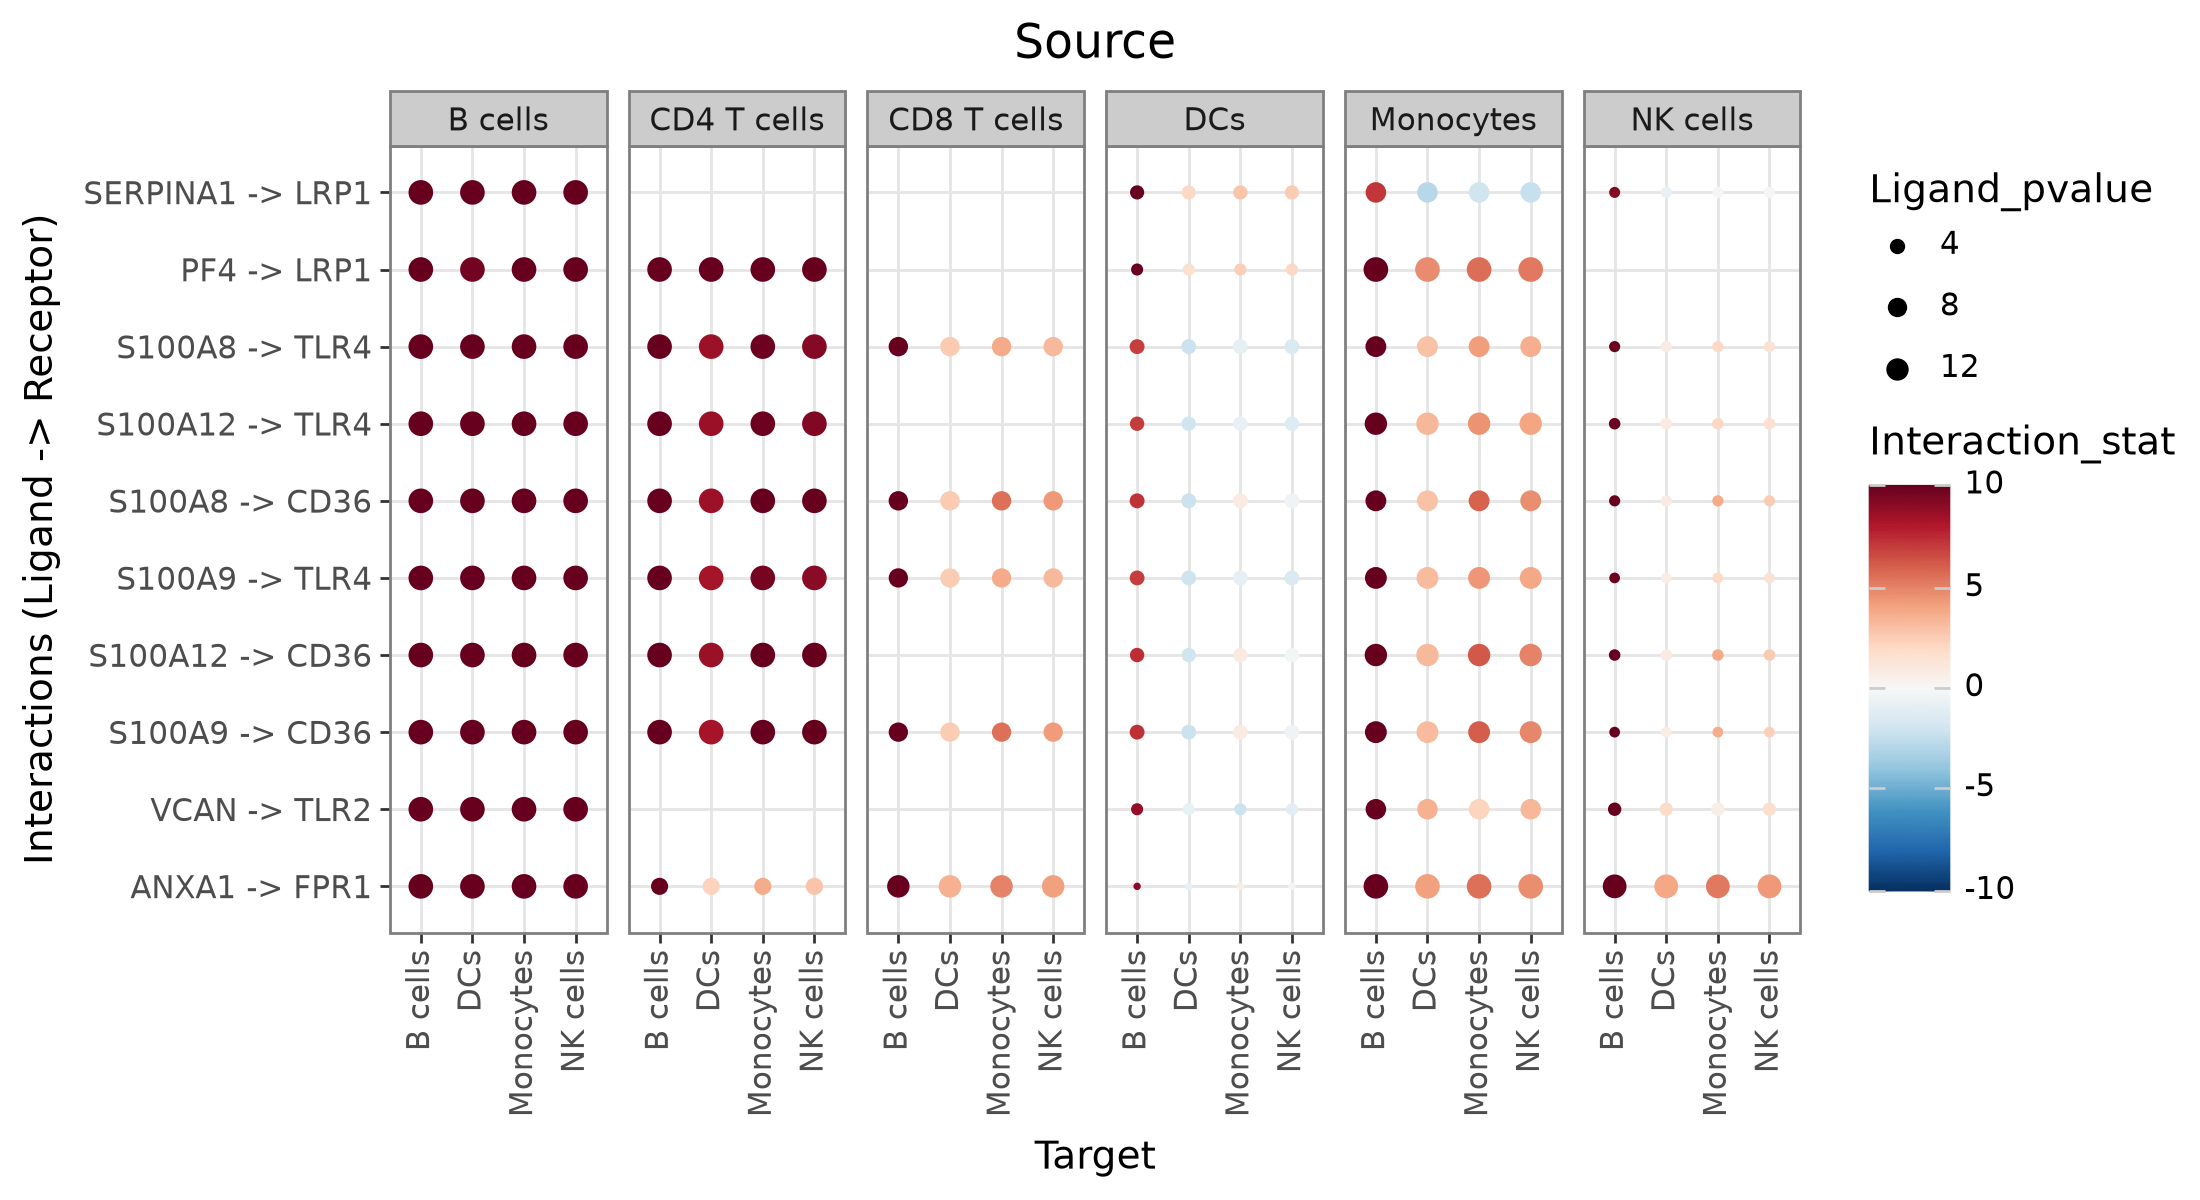

In [79]:
plot = li.pl.dotplot(liana_res=lr_res,
                     colour='interaction_stat',
                     size='ligand_pvalue',
                     inverse_size=True,
                     orderby='interaction_stat',
                     orderby_ascending=False,
                     orderby_absolute=True,
                     top_n=10,
                     size_range=(0.5, 4)
                     )

# customize plot
(
    plot
    + p9.theme_bw(base_size=14)
    # fill cmap blue to red, with 0 the middle
    + p9.scale_color_cmap('RdBu_r', limits=(-10, 10))
    # rotate x
    + p9.theme(axis_text_x=p9.element_text(angle=90), figure_size=(11, 6))

)